In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):

    data = []

    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
df.head()



Total samples: 1467

Emotion distribution:
emotion
happy       306
angry       306
sad         306
surprise    306
neutral     243
Name: count, dtype: int64


,file_path,emotion_code,emotion,duration_sec,sample_rate
0,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,01,happy,3.474771,48000
1,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,03,angry,3.440292,48000
2,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,03,angry,3.622313,48000
3,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.067521,48000
4,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,03,angry,3.548250,48000


### Bi-Lstm with focal loss

Train: 1173, Validation: 147, Test: 147


<ipython-input-2-cfdf0621c534>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-2-cfdf0621c534>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-2-cfdf0621c534>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


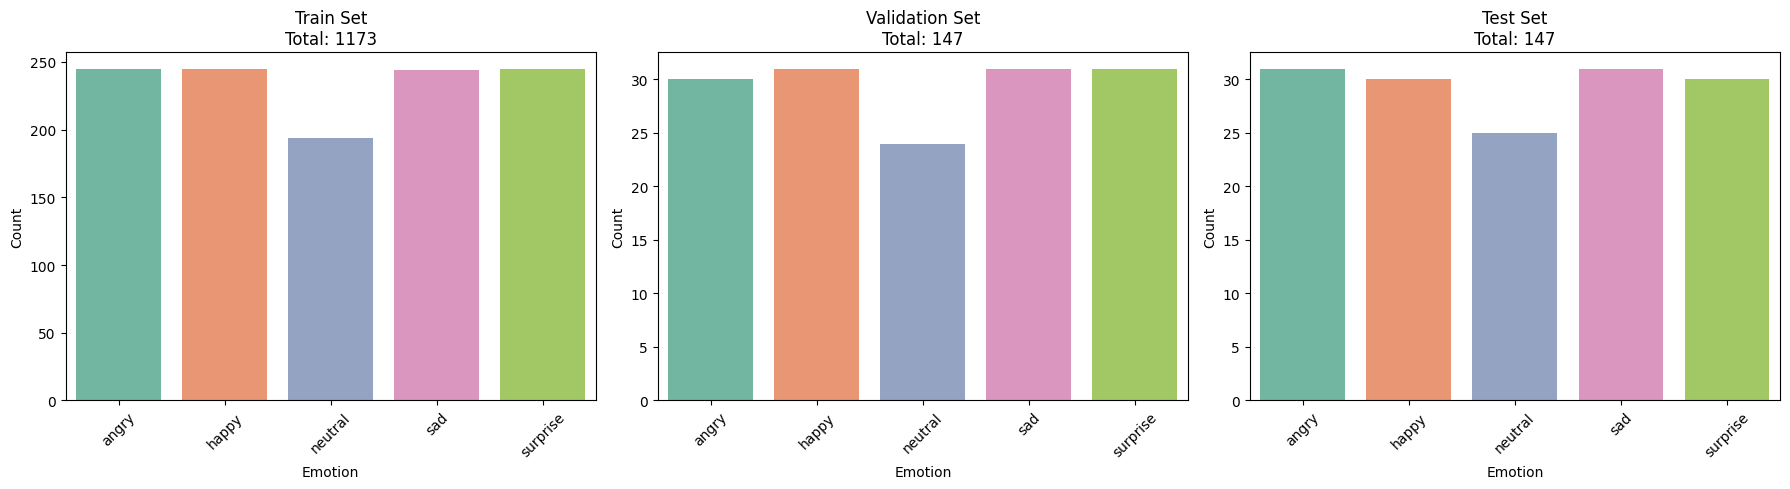

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


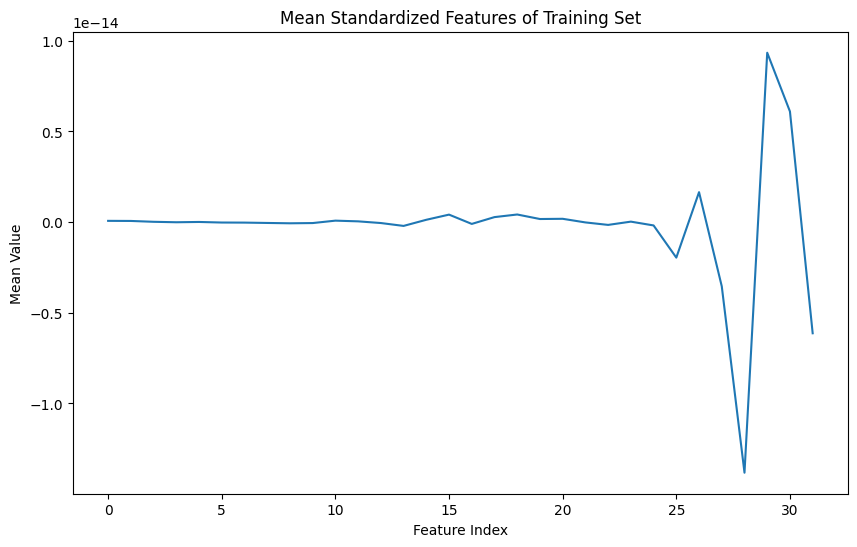

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 32)
X_val reshaped shape: (147, 1, 32)
X_test reshaped shape: (147, 1, 32)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,797 (1.29 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8020 - loss: 0.0530 - val_accuracy: 0.7483 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 10/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8436 - loss: 0.0432
Epoch 10: val_accuracy did not improve from 0.74830
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8432 - loss: 0.0433 - val_accuracy: 0.7211 - val_loss: 0.0881 - learning_rate: 0.0010
Epoch 11/50
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8189 - loss: 0.0452
Epoch 11: val_accuracy improved from 0.74830 to 0.75510, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8203 - loss: 0.0449 - val_accuracy: 0.7551 - val_loss: 0.0898 - learning_rate: 0.0010
Epoch 12/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8509 - loss: 0.0331
Epoch 12: val_accuracy did not improve from 0.75510
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8508 - loss: 0.0332 - val_accuracy: 0.7415 - val_loss: 0.0863 - learning_rate: 0.0010
Epoch 13/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8951 - loss: 0.0265
Epoch 13: val_accuracy did not improve from 0.75510
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8940 - loss: 0.0267 - val_accuracy: 0.7347 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 14/50
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8707 - loss: 0.0314
Epoch 14: val_accuracy did not improve from 0.75510
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8717 - loss: 0.0313 - val_accuracy: 0.7279 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 15/50
36/37 ━━━━━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9139 - loss: 0.0223 - val_accuracy: 0.7687 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 17/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9242 - loss: 0.0189
Epoch 17: val_accuracy did not improve from 0.76871
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9237 - loss: 0.0190 - val_accuracy: 0.7415 - val_loss: 0.1020 - learning_rate: 0.0010
Epoch 18/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9104 - loss: 0.0211
Epoch 18: val_accuracy did not improve from 0.76871
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9107 - loss: 0.0211 - val_accuracy: 0.7687 - val_loss: 0.0990 - learning_rate: 0.0010
Epoch 19/50
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9167 - loss: 0.0194
Epoch 19: val_accuracy improved from 0.76871 to 0.77551, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9185 - loss: 0.0191 - val_accuracy: 0.7755 - val_loss: 0.0970 - learning_rate: 2.0000e-04
Epoch 20/50
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9451 - loss: 0.0141
Epoch 20: val_accuracy did not improve from 0.77551
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9450 - loss: 0.0141 - val_accuracy: 0.7755 - val_loss: 0.0969 - learning_rate: 2.0000e-04
Epoch 21/50
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9515 - loss: 0.0124
Epoch 21: val_accuracy did not improve from 0.77551
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9504 - loss: 0.0124 - val_accuracy: 0.7755 - val_loss: 0.0972 - learning_rate: 2.0000e-04
Epoch 22/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9598 - loss: 0.0105
Epoch 22: val_accuracy did not improve from 0.77551
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9596 - loss: 0.0105 - val_accuracy: 0.7755 - val_loss: 0.0988 - learning_rate: 2.0000e-04
Epoch 23/5

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9462 - loss: 0.0112 - val_accuracy: 0.7823 - val_loss: 0.1002 - learning_rate: 2.0000e-04


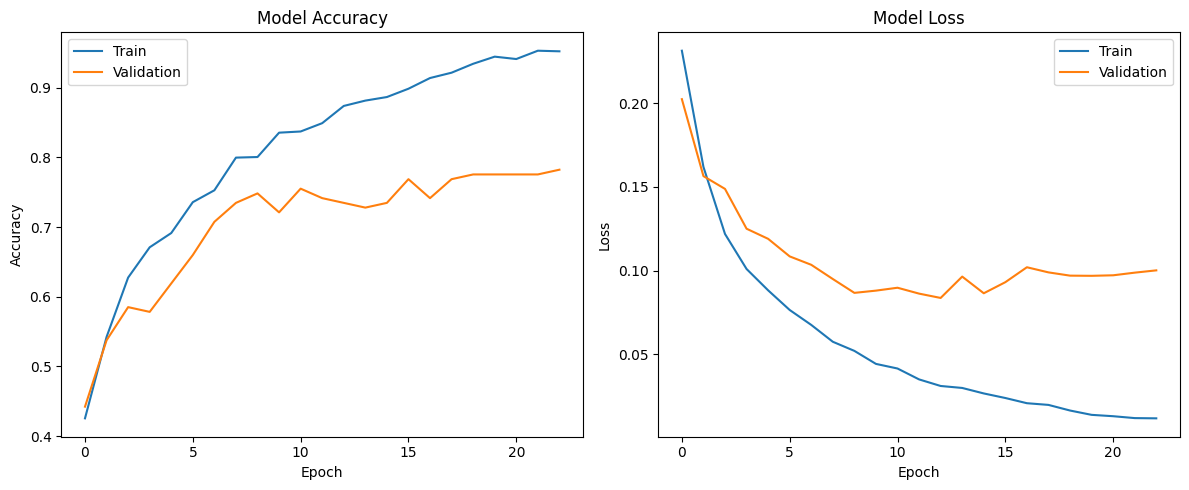

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7106 - loss: 0.0950
Test Loss: 0.0932
Test Accuracy: 0.7347
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.89      0.77      0.83        31
       happy       0.47      0.63      0.54        30
     neutral       0.96      0.92      0.94        25
         sad       0.89      0.77      0.83        31
    surprise       0.62      0.60      0.61        30

    accuracy                           0.73       147
   macro avg       0.77      0.74      0.75       147
weighted avg       0.76      0.73      0.74       147



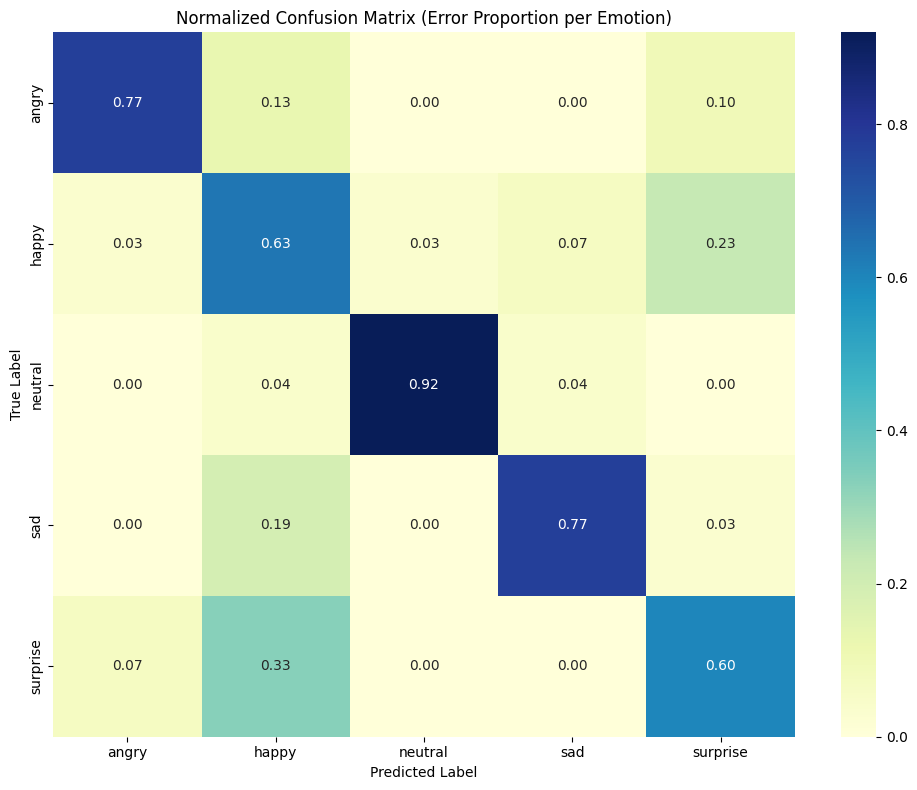

Model saved as 'bangla_ser_model.h5'


In [ ]:

# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Fixed focal loss function using tf.keras.backend instead of keras.backend
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        # Clip predictions to avoid log(0) errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculate cross-entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Modulating factor: (1 - p_t)^γ
        modulating_factor = tf.pow(1. - y_pred, gamma)

        # Apply α (class weights) if provided as a list/tensor
        if isinstance(alpha, (list, tuple)) or isinstance(alpha, tf.Tensor):
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            focal_weight = alpha_tensor * modulating_factor
        else:
            focal_weight = alpha * modulating_factor

        # Final loss: α * (1 - p_t)^γ * Cross-Entropy
        loss = focal_weight * cross_entropy

        # Return average loss across batches
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

# Build BiLSTM model
def build_bilstm_model(input_shape, num_classes):
    model = models.Sequential()

    # First BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True), input_shape=input_shape))

    # Second BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))

    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D())

    # Dense Layer
    model.add(layers.Dense(64, activation='relu'))

    # Dropout for regularization (added)
    model.add(layers.Dropout(0.3))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model (missing in original code)
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]
model = build_bilstm_model(input_shape, num_classes)

# Compile with focal loss to handle class imbalance
model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.0001
    )
]

# Train the model (missing in original code)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set (missing in original code)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_model.h5')
print("Model saved as 'bangla_ser_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

### Bi-LSTM & categorical cross entropy loss and weights added

<ipython-input-3-33c9ff8328a0>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-3-33c9ff8328a0>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


Train: 1173, Validation: 147, Test: 147


<ipython-input-3-33c9ff8328a0>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


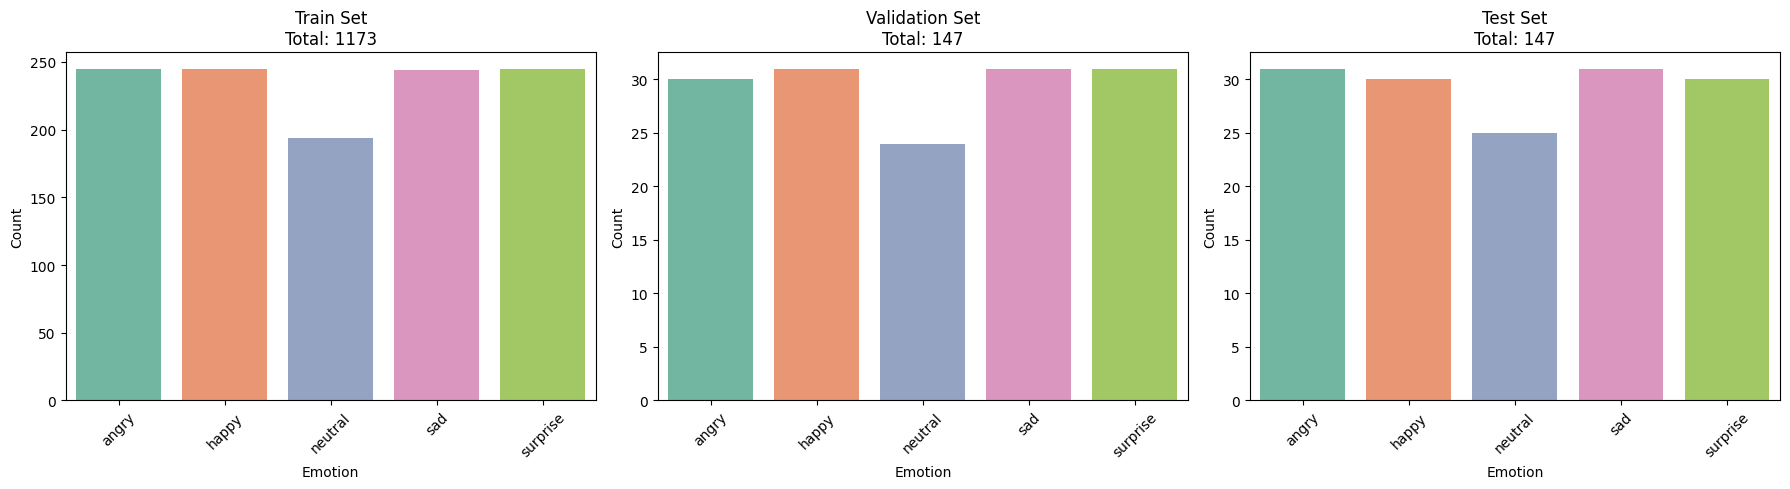

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


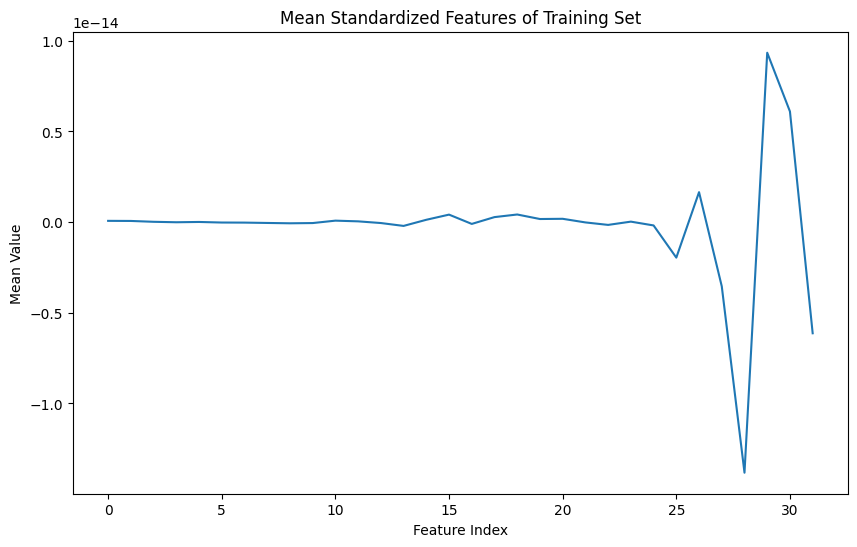

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 32)
X_val reshaped shape: (147, 1, 32)
X_test reshaped shape: (147, 1, 32)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 1, 256)         │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 1, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,845 (1.36 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9043 - loss: 0.2884 - val_accuracy: 0.8027 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 17/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9170 - loss: 0.2504
Epoch 17: val_accuracy improved from 0.80272 to 0.80952, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9163 - loss: 0.2509 - val_accuracy: 0.8095 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 18/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9224 - loss: 0.2189
Epoch 18: val_accuracy improved from 0.80952 to 0.82313, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9216 - loss: 0.2207 - val_accuracy: 0.8231 - val_loss: 0.5087 - learning_rate: 0.0010
Epoch 19/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9281 - loss: 0.1951
Epoch 19: val_accuracy did not improve from 0.82313
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9278 - loss: 0.1965 - val_accuracy: 0.8095 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 20/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9340 - loss: 0.2288
Epoch 20: val_accuracy did not improve from 0.82313
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9325 - loss: 0.2301 - val_accuracy: 0.8095 - val_loss: 0.6381 - learning_rate: 0.0010
Epoch 21/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9179 - loss: 0.2312
Epoch 21: val_accuracy improved from 0.82313 to 0.85034, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9178 - loss: 0.2309 - val_accuracy: 0.8503 - val_loss: 0.4925 - learning_rate: 0.0010
Epoch 22/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9239 - loss: 0.1948
Epoch 22: val_accuracy did not improve from 0.85034
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9240 - loss: 0.1949 - val_accuracy: 0.8367 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 23/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9409 - loss: 0.1685
Epoch 23: val_accuracy did not improve from 0.85034
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9403 - loss: 0.1697 - val_accuracy: 0.8503 - val_loss: 0.5949 - learning_rate: 0.0010
Epoch 24/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9418 - loss: 0.1605
Epoch 24: val_accuracy did not improve from 0.85034
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9414 - loss: 0.1619 - val_accuracy: 0.7959 - val_loss: 0.7278 - learning_rate: 0.0010
Epoch 25/100
35/37 ━━━━


Epoch 31: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9711 - loss: 0.0956 - val_accuracy: 0.8571 - val_loss: 0.6581 - learning_rate: 2.0000e-04
Epoch 32/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9786 - loss: 0.0767
Epoch 32: val_accuracy did not improve from 0.85714
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9785 - loss: 0.0768 - val_accuracy: 0.8571 - val_loss: 0.6592 - learning_rate: 4.0000e-05
Epoch 33/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9723 - loss: 0.0820
Epoch 33: val_accuracy did not improve from 0.85714
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9726 - loss: 0.0818 - val_accuracy: 0.8571 - val_loss: 0.6601 - learning_rate: 4.0000e-05
Epoch 34/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9692 - loss: 0.0919
Epoch 34: val_accuracy did not improve from 0.85714
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9696 - loss: 0.090

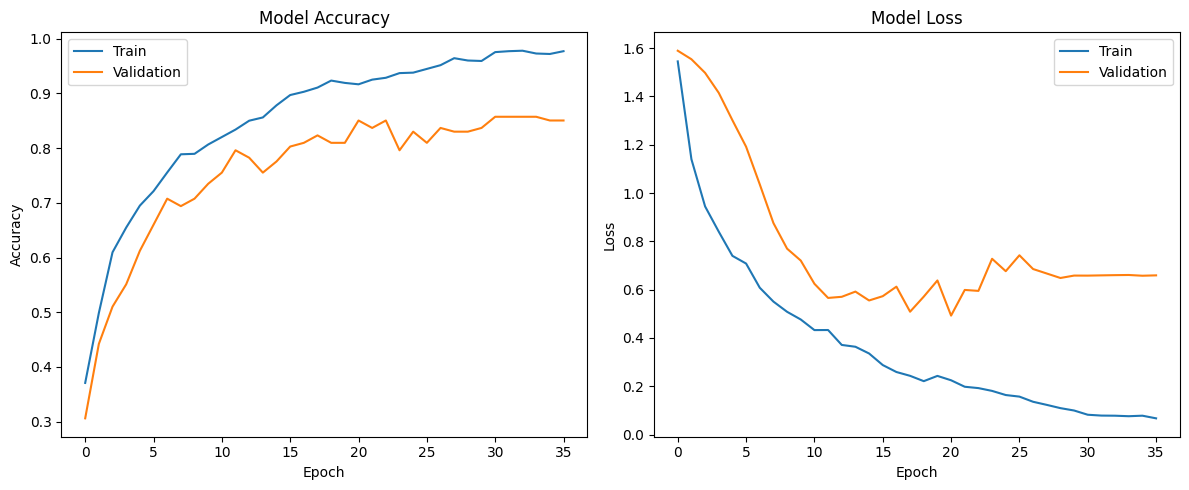

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7535 - loss: 0.8184 
Test Loss: 0.7060
Test Accuracy: 0.7619
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.82      0.90      0.86        31
       happy       0.52      0.53      0.52        30
     neutral       1.00      1.00      1.00        25
         sad       0.88      0.71      0.79        31
    surprise       0.66      0.70      0.68        30

    accuracy                           0.76       147
   macro avg       0.78      0.77      0.77       147
weighted avg       0.77      0.76      0.76       147



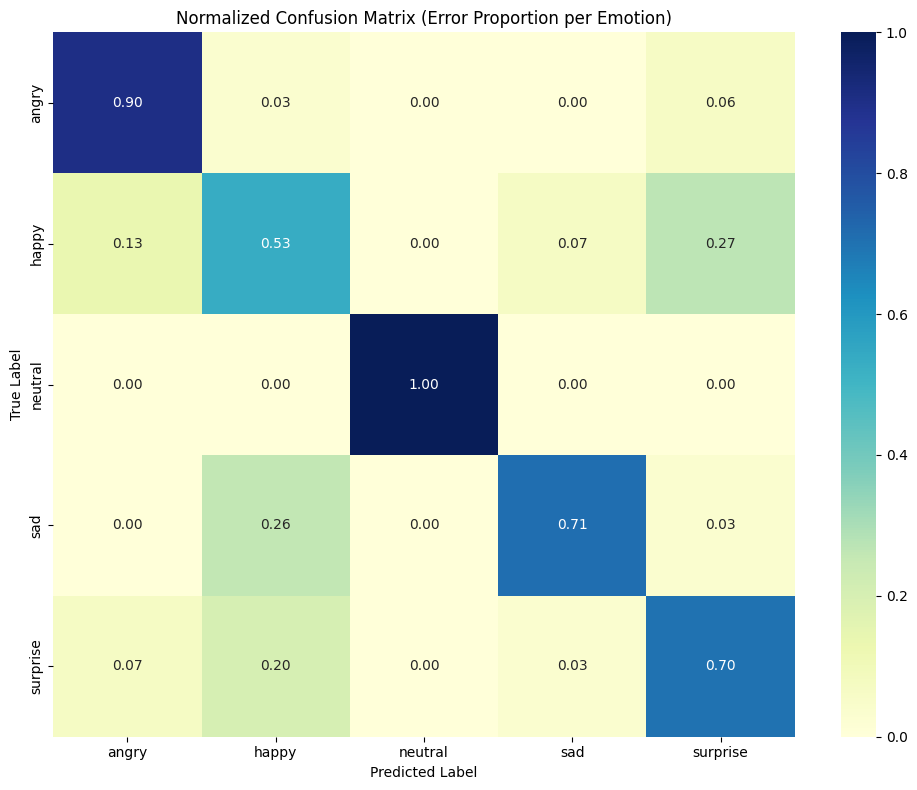

Model saved as 'bangla_ser_bi-lstm_model.h5'


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Build BiLSTM model
def build_bilstm_model(input_shape, num_classes):
    model = models.Sequential()

    # First BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True), input_shape=input_shape))

    # Add Batch Normalization for better training stability
    model.add(layers.BatchNormalization())

    # Second BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))

    # Another Batch Normalization
    model.add(layers.BatchNormalization())

    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D())

    # Dense Layer with more units
    model.add(layers.Dense(128, activation='relu'))

    # Dropout for regularization
    model.add(layers.Dropout(0.5))

    # Another Dense Layer
    model.add(layers.Dense(64, activation='relu'))

    # Dropout for regularization
    model.add(layers.Dropout(0.3))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]
model = build_bilstm_model(input_shape, num_classes)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_bi-lstm_model.h5')
print("Model saved as 'bangla_ser_bi-lstm_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

# Test prediction on a few samples with visualization
def visualize_predictions(num_samples=5):
    # Select random samples from test set
    sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)

    plt.figure(figsize=(15, num_samples*3))

    for i, idx in enumerate(sample_indices):
        sample_path = test_df['file_path'].iloc[idx]
        true_emotion = test_df['emotion'].iloc[idx]

        # Predict
        predicted_emotion, confidence, all_probs = predict_emotion(sample_path, model, scaler, label_encoder)

        # Plot audio waveform
        plt.subplot(num_samples, 2, 2*i+1)
        y, sr = librosa.load(sample_path, sr=None)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Sample {i+1}: True={true_emotion}, Pred={predicted_emotion} ({confidence:.2f})")

        # Plot prediction probabilities
        plt.subplot(num_samples, 2, 2*i+2)
        sns.barplot(x=label_encoder.classes_, y=all_probs)
        plt.title(f"Prediction Probabilities")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Uncomment to visualize predictions on test samples
# visualize_predictions(5)

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence, _ = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

### CNN

<ipython-input-4-d33817e0349f>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-4-d33817e0349f>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


Train: 1173, Validation: 147, Test: 147


<ipython-input-4-d33817e0349f>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


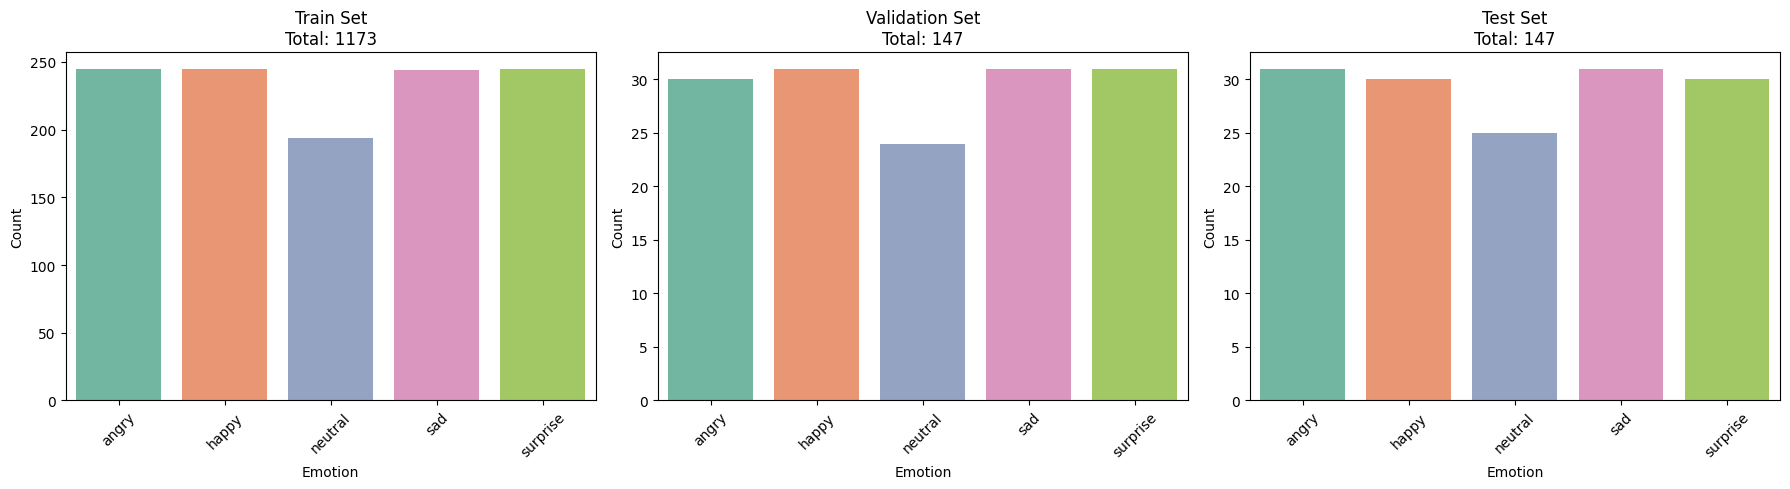

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


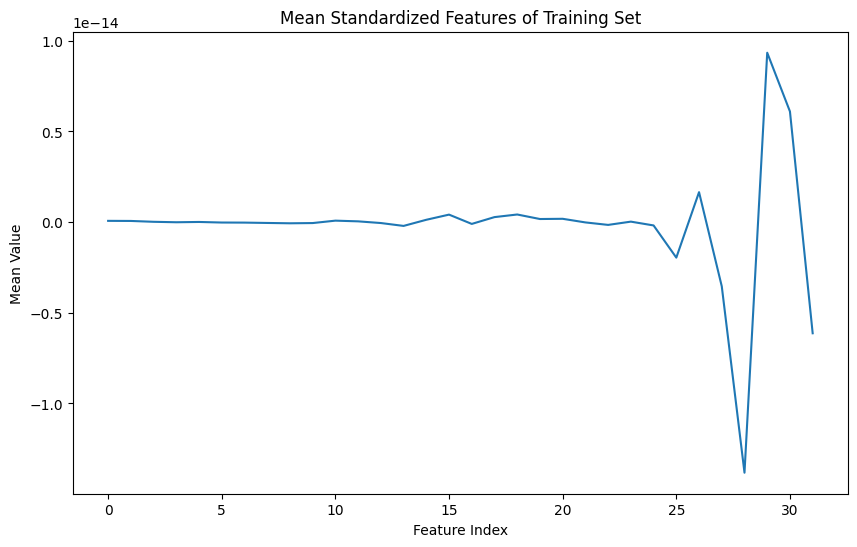

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 32, 1)
X_val reshaped shape: (147, 32, 1)
X_test reshaped shape: (147, 32, 1)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 32, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,093 (1.01 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7879 - loss: 0.5580 - val_accuracy: 0.7755 - val_loss: 0.6437 - learning_rate: 0.0010
Epoch 13/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8113 - loss: 0.4404
Epoch 13: val_accuracy did not improve from 0.77551
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8109 - loss: 0.4422 - val_accuracy: 0.7075 - val_loss: 0.7942 - learning_rate: 0.0010
Epoch 14/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8188 - loss: 0.4359
Epoch 14: val_accuracy did not improve from 0.77551
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8210 - loss: 0.4340 - val_accuracy: 0.7483 - val_loss: 0.7074 - learning_rate: 0.0010
Epoch 15/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8764 - loss: 0.3618
Epoch 15: val_accuracy improved from 0.77551 to 0.80952, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8757 - loss: 0.3630 - val_accuracy: 0.8095 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 16/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8735 - loss: 0.3372
Epoch 16: val_accuracy did not improve from 0.80952
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8733 - loss: 0.3375 - val_accuracy: 0.7823 - val_loss: 0.6602 - learning_rate: 0.0010
Epoch 17/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8866 - loss: 0.2936
Epoch 17: val_accuracy did not improve from 0.80952
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8857 - loss: 0.2956 - val_accuracy: 0.8095 - val_loss: 0.6277 - learning_rate: 0.0010
Epoch 18/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9134 - loss: 0.2461
Epoch 18: val_accuracy did not improve from 0.80952
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9127 - loss: 0.2476 - val_accuracy: 0.7551 - val_loss: 0.7662 - learning_rate: 0.0010
Epoch 19/100
36/37 ━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8999 - loss: 0.2622 - val_accuracy: 0.8231 - val_loss: 0.6801 - learning_rate: 0.0010
Epoch 20/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9064 - loss: 0.2490
Epoch 20: val_accuracy improved from 0.82313 to 0.83673, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9065 - loss: 0.2485 - val_accuracy: 0.8367 - val_loss: 0.5707 - learning_rate: 0.0010
Epoch 21/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9234 - loss: 0.2052
Epoch 21: val_accuracy did not improve from 0.83673
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9227 - loss: 0.2063 - val_accuracy: 0.8299 - val_loss: 0.6643 - learning_rate: 0.0010
Epoch 22/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9316 - loss: 0.2114
Epoch 22: val_accuracy did not improve from 0.83673
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9303 - loss: 0.2129 - val_accuracy: 0.7687 - val_loss: 0.7849 - learning_rate: 0.0010
Epoch 23/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9189 - loss: 0.2340
Epoch 23: val_accuracy did not improve from 0.83673
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9190 - loss: 0.2339 - val_accuracy: 0.8027 - val_loss: 0.7530 - learning_rate: 0.0010
Epoch 24/100
37/37 ━━━━


Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9216 - loss: 0.1972 - val_accuracy: 0.8707 - val_loss: 0.5850 - learning_rate: 0.0010
Epoch 26/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9498 - loss: 0.1380
Epoch 26: val_accuracy did not improve from 0.87075
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9497 - loss: 0.1379 - val_accuracy: 0.8571 - val_loss: 0.5618 - learning_rate: 2.0000e-04
Epoch 27/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9769 - loss: 0.0818
Epoch 27: val_accuracy did not improve from 0.87075
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9767 - loss: 0.0817 - val_accuracy: 0.8503 - val_loss: 0.5653 - learning_rate: 2.0000e-04
Epoch 28/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9785 - loss: 0.0710
Epoch 28: val_accuracy did not improve from 0.87075
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9780 - loss: 0.0716 - 

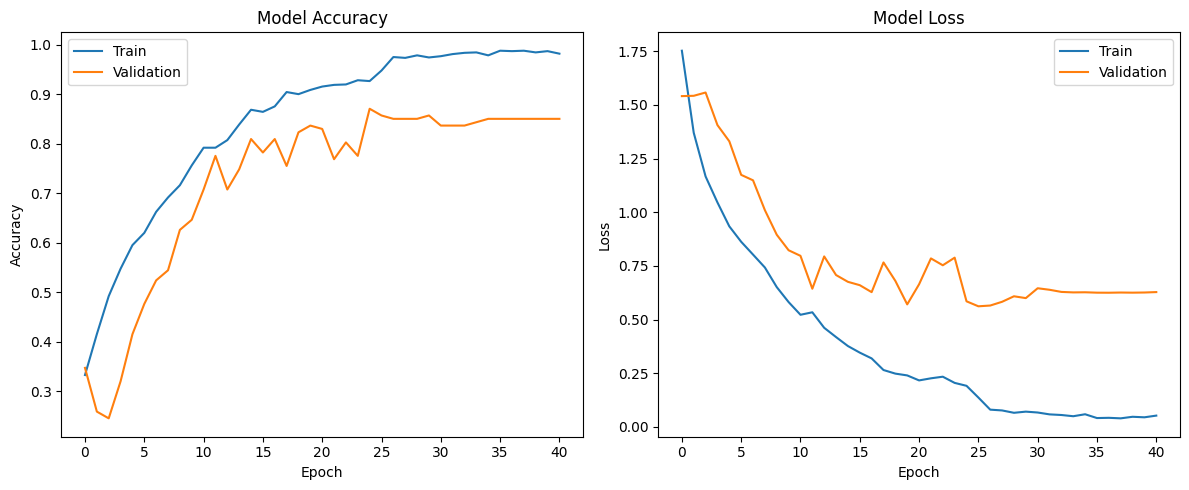

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7614 - loss: 0.9663
Test Loss: 0.7153
Test Accuracy: 0.7959


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.82      0.90      0.86        31
       happy       0.71      0.57      0.63        30
     neutral       0.89      1.00      0.94        25
         sad       0.84      0.84      0.84        31
    surprise       0.70      0.70      0.70        30

    accuracy                           0.80       147
   macro avg       0.79      0.80      0.79       147
weighted avg       0.79      0.80      0.79       147



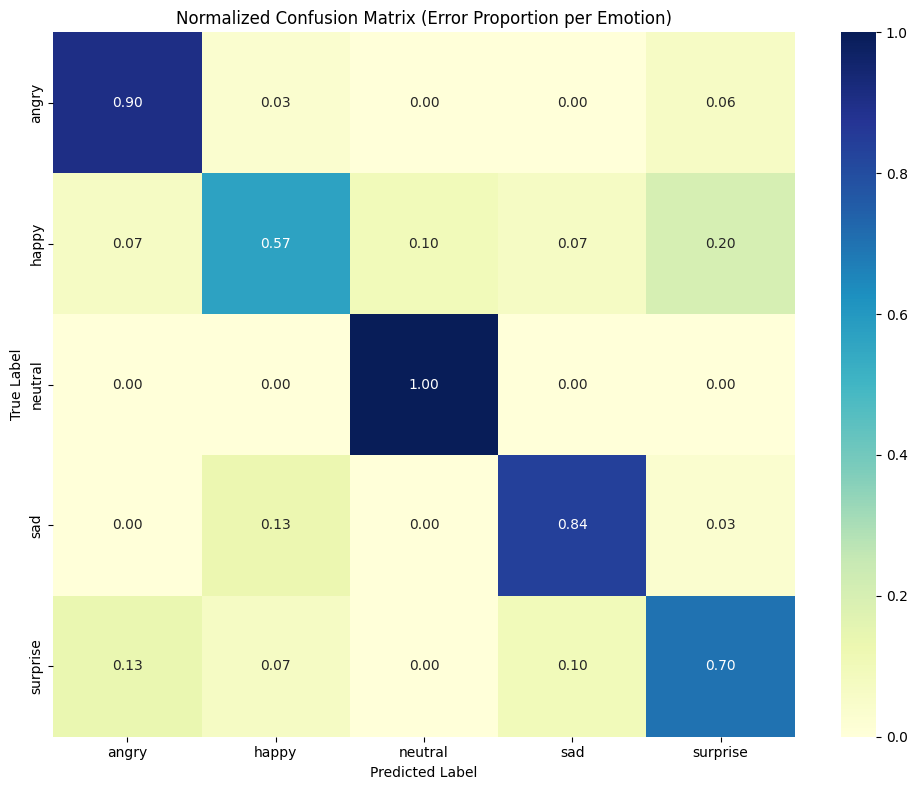

Model saved as 'bangla_ser_cnn_model.h5'


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for CNN model input (adding channel dimension)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Build CNN model
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential()

    # First Convolutional Layer
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Second Convolutional Layer
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Third Convolutional Layer
    model.add(layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Flatten the output
    model.add(layers.Flatten())

    # Dense layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]
model = build_cnn_model(input_shape, num_classes)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_cnn_model.h5')
print("Model saved as 'bangla_ser_cnn_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for model input
    features = features.reshape(1, -1, 1)  # Reshape for CNN (batch_size, feature_length, channels)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

# Test prediction on a few samples with visualization
def visualize_predictions(num_samples=5):
    # Select random samples from test set
    sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)

    plt.figure(figsize=(15, num_samples*3))

    for i, idx in enumerate(sample_indices):
        sample_path = test_df['file_path'].iloc[idx]
        true_emotion = test_df['emotion'].iloc[idx]

        # Predict
        predicted_emotion, confidence, all_probs = predict_emotion(sample_path, model, scaler, label_encoder)

        # Plot audio waveform
        plt.subplot(num_samples, 2, 2*i+1)
        y, sr = librosa.load(sample_path, sr=None)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Sample {i+1}: True={true_emotion}, Pred={predicted_emotion} ({confidence:.2f})")

        # Plot prediction probabilities
        plt.subplot(num_samples, 2, 2*i+2)
        sns.barplot(x=label_encoder.classes_, y=all_probs)
        plt.title(f"Prediction Probabilities")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Uncomment to visualize predictions on test samples
# visualize_predictions(5)

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence, _ = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

### using YamNET

Added YAMNet integration:

Imported TensorFlow Hub to load the pre-trained YAMNet model
Loading YAMNet from TensorFlow Hub: yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')


Replaced the feature extraction function:

Now uses YAMNet to extract embeddings from audio files
Resamples audio to 16kHz as required by YAMNet
Ensures audio is mono and in float32 format
Extracts embeddings and takes the mean to get a fixed-length feature vector


Simplified data processing:

Removed reshaping for CNN as YAMNet embeddings are already flat vectors
Updated data visualization labels to reflect YAMNet embeddings


Created a new model architecture:

Built a new build_yamnet_emotion_model() function with:

Dense layers acting on YAMNet embeddings
BatchNormalization and Dropout for regularization
Final softmax layer for emotion classification

<ipython-input-5-c4e9660537fb>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-5-c4e9660537fb>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


Train: 1173, Validation: 147, Test: 147


<ipython-input-5-c4e9660537fb>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


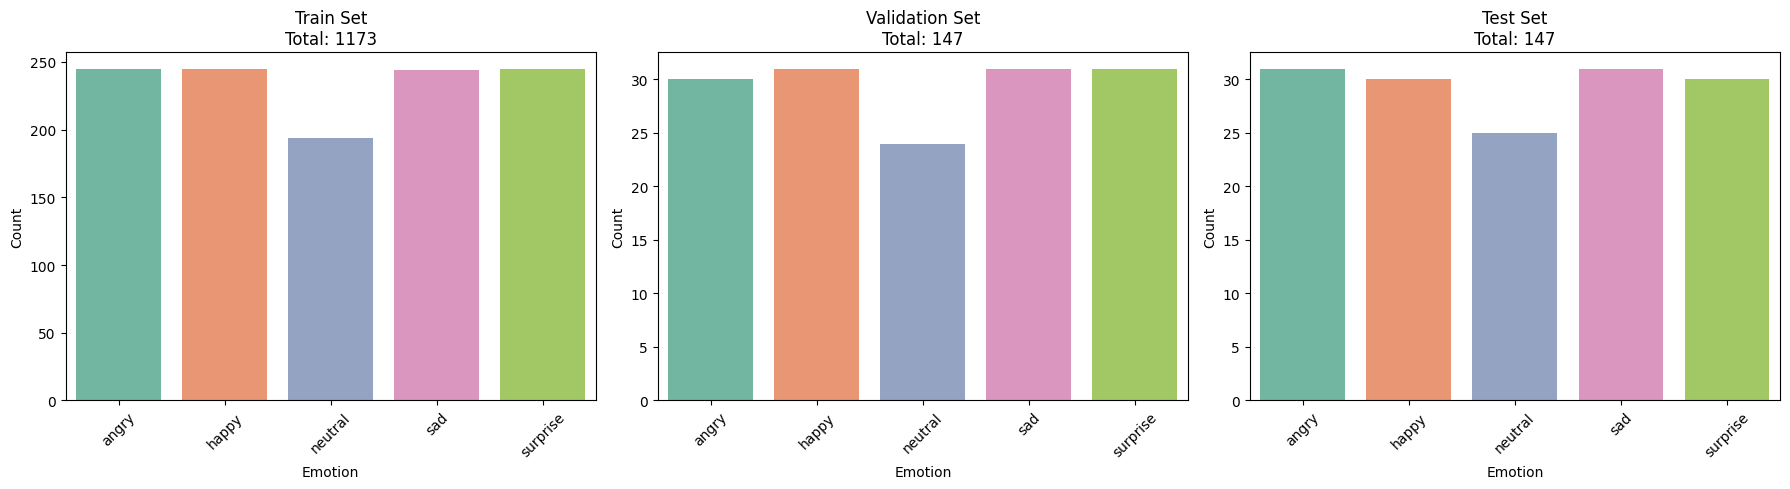

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 1024)


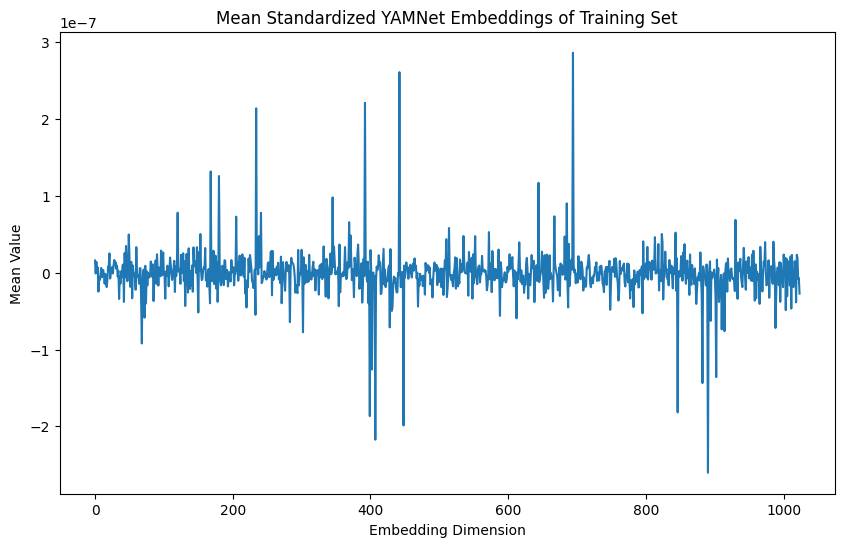

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train shape: (1173, 1024)
X_val shape: (147, 1024)
X_test shape: (147, 1024)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,669 (1.17 MB)

 Trainable params: 304,773 (1.16 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5241 - loss: 1.1508 - val_accuracy: 0.5510 - val_loss: 1.1363 - learning_rate: 0.0010
Epoch 14/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4938 - loss: 1.1797
Epoch 14: val_accuracy did not improve from 0.55102
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4945 - loss: 1.1783 - val_accuracy: 0.5374 - val_loss: 1.1116 - learning_rate: 0.0010
Epoch 15/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5243 - loss: 1.1142
Epoch 15: val_accuracy improved from 0.55102 to 0.57143, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5241 - loss: 1.1151 - val_accuracy: 0.5714 - val_loss: 1.0696 - learning_rate: 0.0010
Epoch 16/100
31/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5169 - loss: 1.1501
Epoch 16: val_accuracy did not improve from 0.57143
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5185 - loss: 1.1479 - val_accuracy: 0.5306 - val_loss: 1.1255 - learning_rate: 0.0010
Epoch 17/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5446 - loss: 1.1351
Epoch 17: val_accuracy did not improve from 0.57143
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5456 - loss: 1.1328 - val_accuracy: 0.5102 - val_loss: 1.1354 - learning_rate: 0.0010
Epoch 18/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5277 - loss: 1.1243
Epoch 18: val_accuracy did not improve from 0.57143
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5286 - loss: 1.1220 - val_accuracy: 0.5374 - val_loss: 1.0655 - learning_rate: 0.0010
Epoch 19/100
35/37 ━━━━━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6138 - loss: 0.9641 - val_accuracy: 0.6122 - val_loss: 0.9987 - learning_rate: 0.0010
Epoch 23/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6081 - loss: 0.9193
Epoch 23: val_accuracy did not improve from 0.61224
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6076 - loss: 0.9210 - val_accuracy: 0.5714 - val_loss: 1.0743 - learning_rate: 0.0010
Epoch 24/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6168 - loss: 0.9586
Epoch 24: val_accuracy did not improve from 0.61224
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6155 - loss: 0.9599 - val_accuracy: 0.5714 - val_loss: 1.0152 - learning_rate: 0.0010
Epoch 25/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6275 - loss: 0.9201
Epoch 25: val_accuracy did not improve from 0.61224
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6269 - loss: 0.9199 - val_accuracy: 0.5986 - val_loss: 0.9863 - learning_rate: 0.0010
Epoch 26/100
35/37 ━━━━━━━

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6558 - loss: 0.8542 - val_accuracy: 0.6327 - val_loss: 0.9587 - learning_rate: 2.0000e-04
Epoch 32/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6734 - loss: 0.8002
Epoch 32: val_accuracy did not improve from 0.63265
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6728 - loss: 0.8012 - val_accuracy: 0.6327 - val_loss: 0.9580 - learning_rate: 2.0000e-04
Epoch 33/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6854 - loss: 0.7955
Epoch 33: val_accuracy did not improve from 0.63265
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6844 - loss: 0.7970 - val_accuracy: 0.6259 - val_loss: 0.9485 - learning_rate: 2.0000e-04
Epoch 34/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6655 - loss: 0.7703
Epoch 34: val_accuracy did not improve from 0.63265
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6656 - loss: 0.7710 - val_accuracy: 0.6190 - val_loss: 0.9542 - learning_rate: 2.0000e-04
Epoch 35/

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6855 - loss: 0.7532 - val_accuracy: 0.6667 - val_loss: 0.9442 - learning_rate: 2.0000e-04
Epoch 37/100
35/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6461 - loss: 0.8257
Epoch 37: val_accuracy did not improve from 0.66667
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6490 - loss: 0.8213 - val_accuracy: 0.6122 - val_loss: 0.9663 - learning_rate: 2.0000e-04
Epoch 38/100
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7196 - loss: 0.7072
Epoch 38: val_accuracy did not improve from 0.66667
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7192 - loss: 0.7077 - val_accuracy: 0.6259 - val_loss: 0.9397 - learning_rate: 2.0000e-04
Epoch 39/100
33/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7078 - loss: 0.6945
Epoch 39: val_accuracy did not improve from 0.66667
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7070 - loss: 0.6969 - val_accuracy: 0.6122 - val_loss: 0.9238 - learning_rate: 2.0000e-04
Epoch 40/1

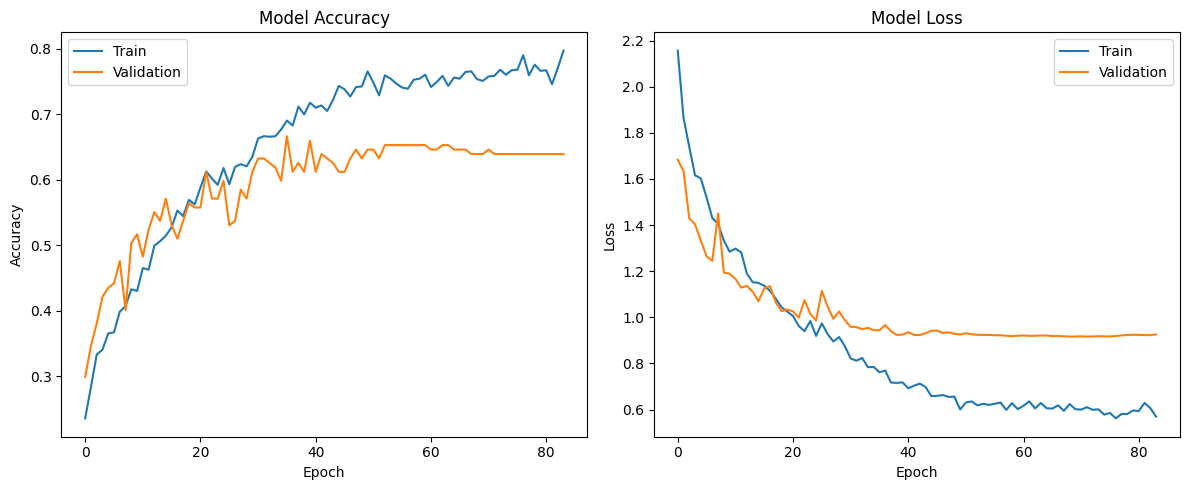

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5821 - loss: 0.9779 
Test Loss: 0.9350
Test Accuracy: 0.6122
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.67      0.71      0.69        31
       happy       0.38      0.37      0.37        30
     neutral       0.88      0.84      0.86        25
         sad       0.71      0.71      0.71        31
    surprise       0.47      0.47      0.47        30

    accuracy                           0.61       147
   macro avg       0.62      0.62      0.62       147
weighted avg       0.61      0.61      0.61       147



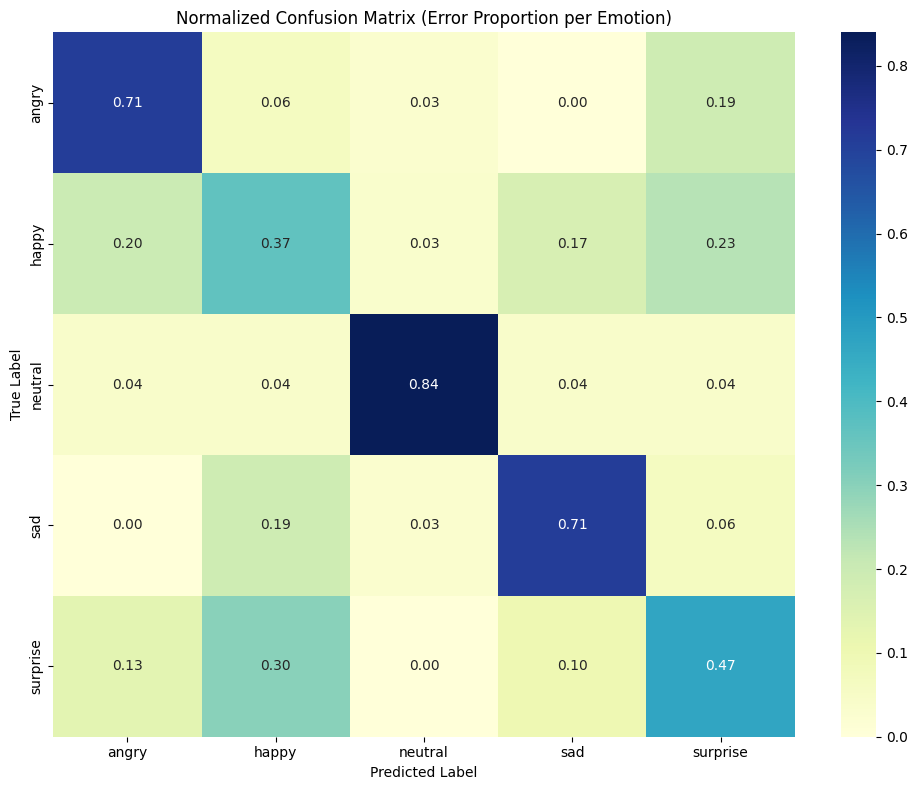

Model saved as 'bangla_ser_yamnet_model.h5'


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Import YAMNet model
import tensorflow_hub as hub
import tensorflow as tf

# Load YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function using YAMNet embeddings
def extract_features(file_path):
    # Load audio file
    wav_data, sr = librosa.load(file_path, sr=16000)  # YAMNet expects 16 kHz mono audio

    # Make sure audio is mono
    if len(wav_data.shape) > 1:
        wav_data = np.mean(wav_data, axis=1)

    # Ensure float32 data type for YAMNet
    wav_data = wav_data.astype(np.float32)

    # Get YAMNet embeddings
    scores, embeddings, log_mel_spectrogram = yamnet_model(wav_data)

    # Take the mean of embeddings across time segments to get a fixed-length feature vector
    mean_embedding = np.mean(embeddings.numpy(), axis=0)

    return mean_embedding

# Import YAMNet model
import tensorflow_hub as hub
import tensorflow as tf

# Load YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function using YAMNet embeddings
def extract_features(file_path):
    # Load audio file
    wav_data, sr = librosa.load(file_path, sr=16000)  # YAMNet expects 16 kHz mono audio

    # Make sure audio is mono
    if len(wav_data.shape) > 1:
        wav_data = np.mean(wav_data, axis=1)

    # Ensure float32 data type for YAMNet
    wav_data = wav_data.astype(np.float32)

    # Get YAMNet embeddings
    scores, embeddings, log_mel_spectrogram = yamnet_model(wav_data)

    # Take the mean of embeddings across time segments to get a fixed-length feature vector
    mean_embedding = np.mean(embeddings.numpy(), axis=0)

    return mean_embedding

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape for the model - no need for additional reshaping with YAMNet embeddings
# YAMNet embeddings are already flattened vectors
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized YAMNet Embeddings of Training Set')
plt.xlabel('Embedding Dimension')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# No need to reshape for CNN as YAMNet features are already a flat vector
# We'll use them directly
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Build model using YAMNet embeddings as input
def build_yamnet_emotion_model(input_shape, num_classes):
    model = models.Sequential()

    # Input layer
    model.add(layers.Input(shape=input_shape))

    # Dense layers for classification
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model
input_shape = (X_train.shape[1],)  # YAMNet embedding dimension
num_classes = y_train.shape[1]
model = build_yamnet_emotion_model(input_shape, num_classes)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_yamnet_model.h5')
print("Model saved as 'bangla_ser_yamnet_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio using YAMNet
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # No need to reshape for YAMNet-based model

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

# Test prediction on a few samples with visualization
def visualize_predictions(num_samples=5):
    # Select random samples from test set
    sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)

    plt.figure(figsize=(15, num_samples*3))

    for i, idx in enumerate(sample_indices):
        sample_path = test_df['file_path'].iloc[idx]
        true_emotion = test_df['emotion'].iloc[idx]

        # Predict
        predicted_emotion, confidence, all_probs = predict_emotion(sample_path, model, scaler, label_encoder)

        # Plot audio waveform
        plt.subplot(num_samples, 2, 2*i+1)
        y, sr = librosa.load(sample_path, sr=None)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Sample {i+1}: True={true_emotion}, Pred={predicted_emotion} ({confidence:.2f})")

        # Plot prediction probabilities
        plt.subplot(num_samples, 2, 2*i+2)
        sns.barplot(x=label_encoder.classes_, y=all_probs)
        plt.title(f"Prediction Probabilities")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Uncomment to visualize predictions on test samples
# visualize_predictions(5)

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence, _ = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

### CNN-Yamnet

Reshaped YAMNet embeddings for CNN processing:

Added a channel dimension to the YAMNet embeddings
The shape is now (batch_size, embedding_dim, 1)


Created a new hybrid CNN-YAMNet architecture:

Built build_cnn_yamnet_model() function that takes YAMNet embeddings as input
Added three convolutional blocks:

First block: Conv1D with 64 filters and kernel size 5
Second block: Conv1D with 128 filters and kernel size 3
Third block: Conv1D with 256 filters and kernel size 3


Each block includes BatchNormalization and pooling layers
Used GlobalAveragePooling1D to handle variable-length inputs
Added dense layers with BatchNormalization and Dropout for classification


Updated prediction function:

Modified to reshape features for CNN-YAMNet model input
Now reshapes to (1, features, 1) format




Train: 1173, Validation: 147, Test: 147


<ipython-input-6-a123b9ca773a>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-6-a123b9ca773a>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-6-a123b9ca773a>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


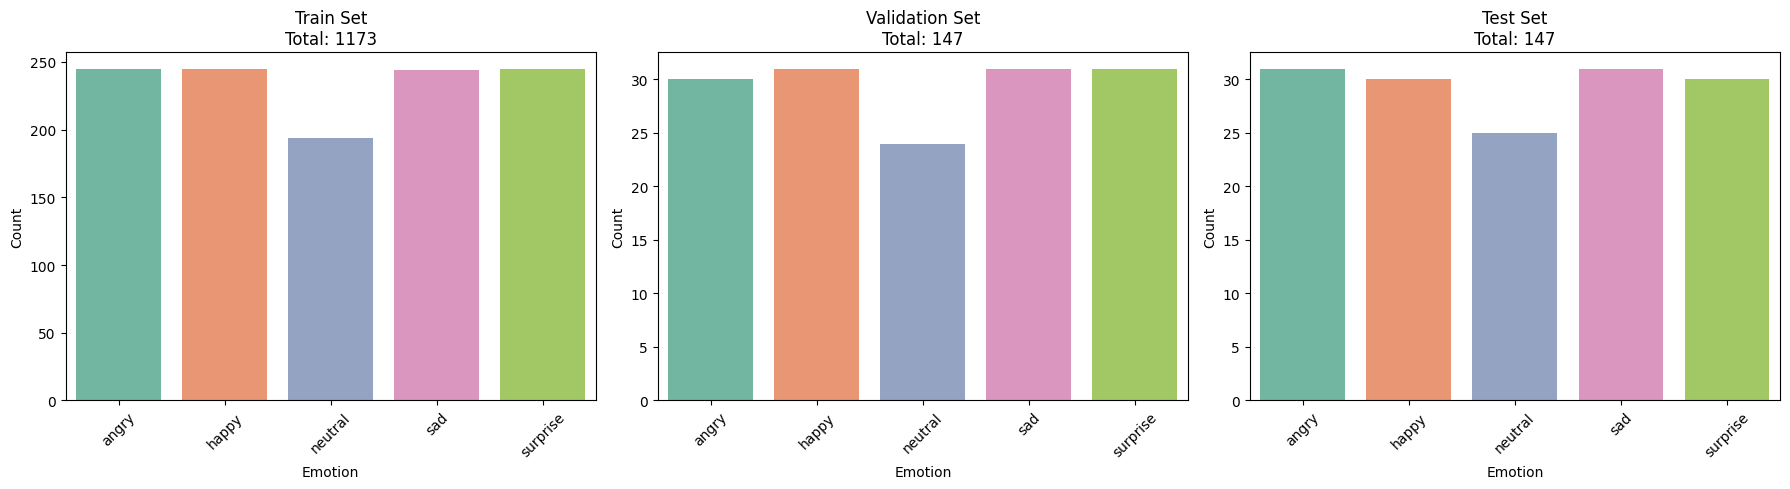

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 1024)


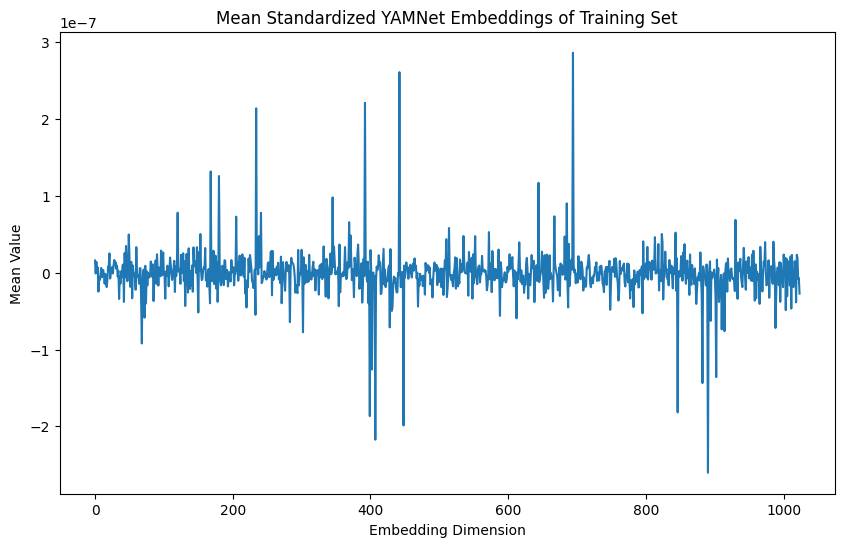

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape for CNN: (1173, 1024, 1)
X_val reshaped shape for CNN: (147, 1024, 1)
X_test reshaped shape for CNN: (147, 1024, 1)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 1024, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 512, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 256, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,685 (655.02 KB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - accuracy: 0.4111 - loss: 1.2272 - val_accuracy: 0.4490 - val_loss: 1.3381 - learning_rate: 2.0000e-04
Epoch 53/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4654 - loss: 1.2045
Epoch 53: val_accuracy did not improve from 0.44898
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.4650 - loss: 1.2048 - val_accuracy: 0.4014 - val_loss: 1.4743 - learning_rate: 2.0000e-04
Epoch 54/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4510 - loss: 1.2125
Epoch 54: val_accuracy did not improve from 0.44898
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 311ms/step - accuracy: 0.4515 - loss: 1.2120 - val_accuracy: 0.3810 - val_loss: 1.4474 - learning_rate: 2.0000e-04
Epoch 55/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.4847 - loss: 1.1812
Epoch 55: val_accuracy did not improve from 0.44898

Epoch 55: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - accuracy: 0.4843 - 

37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 315ms/step - accuracy: 0.5275 - loss: 1.1104 - val_accuracy: 0.4558 - val_loss: 1.3133 - learning_rate: 4.0000e-05
Epoch 59/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.4848 - loss: 1.1314
Epoch 59: val_accuracy improved from 0.45578 to 0.47619, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 283ms/step - accuracy: 0.4849 - loss: 1.1313 - val_accuracy: 0.4762 - val_loss: 1.2925 - learning_rate: 4.0000e-05
Epoch 60/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4886 - loss: 1.1453
Epoch 60: val_accuracy did not improve from 0.47619
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 313ms/step - accuracy: 0.4892 - loss: 1.1447 - val_accuracy: 0.4626 - val_loss: 1.2932 - learning_rate: 4.0000e-05
Epoch 61/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5184 - loss: 1.1063
Epoch 61: val_accuracy did not improve from 0.47619
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 317ms/step - accuracy: 0.5184 - loss: 1.1064 - val_accuracy: 0.4354 - val_loss: 1.3354 - learning_rate: 4.0000e-05
Epoch 62/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5002 - loss: 1.0991
Epoch 62: val_accuracy did not improve from 0.47619
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 308ms/step - accuracy: 0.5007 - loss: 1.0990 - val_accuracy: 0.4762 - val_loss: 1.2864 - learning_rate: 4.0000e

37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step - accuracy: 0.5492 - loss: 1.0440 - val_accuracy: 0.4830 - val_loss: 1.2853 - learning_rate: 1.0000e-05
Epoch 83/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.5519 - loss: 1.0442
Epoch 83: val_accuracy did not improve from 0.48299
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - accuracy: 0.5521 - loss: 1.0439 - val_accuracy: 0.4762 - val_loss: 1.2784 - learning_rate: 1.0000e-05
Epoch 84/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5125 - loss: 1.0707
Epoch 84: val_accuracy did not improve from 0.48299
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 314ms/step - accuracy: 0.5133 - loss: 1.0698 - val_accuracy: 0.4762 - val_loss: 1.2739 - learning_rate: 1.0000e-05
Epoch 85/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.5816 - loss: 1.0193
Epoch 85: val_accuracy did not improve from 0.48299
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.5811 - loss: 1.0198 - val_accuracy: 0.4830 - val_loss: 1.2811 - learning_rate: 1.0000e

37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 303ms/step - accuracy: 0.5579 - loss: 1.0291 - val_accuracy: 0.4966 - val_loss: 1.2846 - learning_rate: 1.0000e-05
Epoch 90/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5503 - loss: 1.0360
Epoch 90: val_accuracy did not improve from 0.49660
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 312ms/step - accuracy: 0.5502 - loss: 1.0361 - val_accuracy: 0.4898 - val_loss: 1.2947 - learning_rate: 1.0000e-05
Epoch 91/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.5440 - loss: 1.0300
Epoch 91: val_accuracy did not improve from 0.49660
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - accuracy: 0.5439 - loss: 1.0302 - val_accuracy: 0.4898 - val_loss: 1.2823 - learning_rate: 1.0000e-05
Epoch 92/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5582 - loss: 1.0245
Epoch 92: val_accuracy did not improve from 0.49660
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 311ms/step - accuracy: 0.5584 - loss: 1.0247 - val_accuracy: 0.4898 - val_loss: 1.2797 - learning_rate: 1.0000e

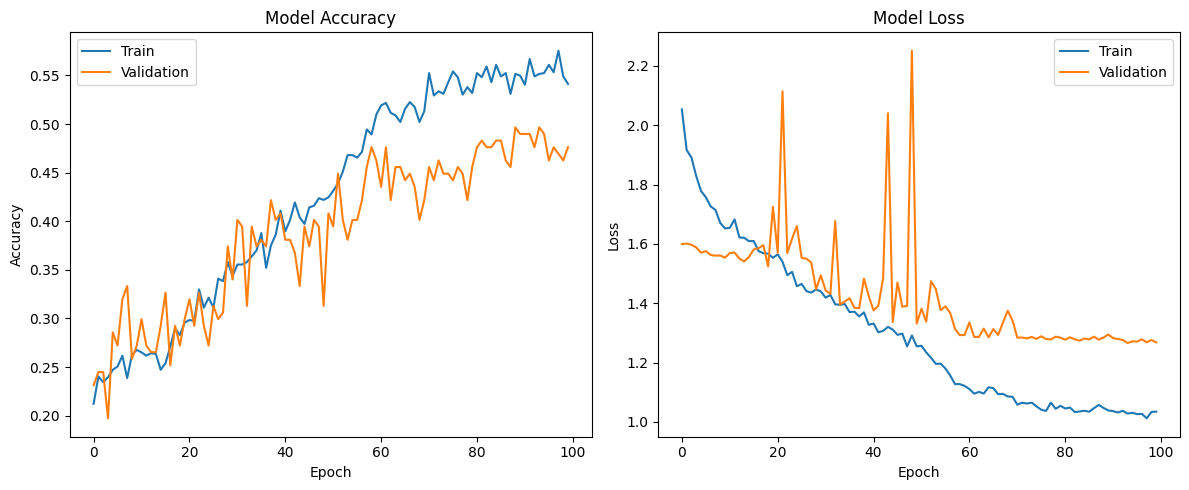

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4543 - loss: 1.2399
Test Loss: 1.2318
Test Accuracy: 0.4762
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.55      0.52        31
       happy       0.44      0.27      0.33        30
     neutral       0.86      0.72      0.78        25
         sad       0.35      0.19      0.25        31
    surprise       0.38      0.70      0.49        30

    accuracy                           0.48       147
   macro avg       0.50      0.49      0.47       147
weighted avg       0.49      0.48      0.46       147



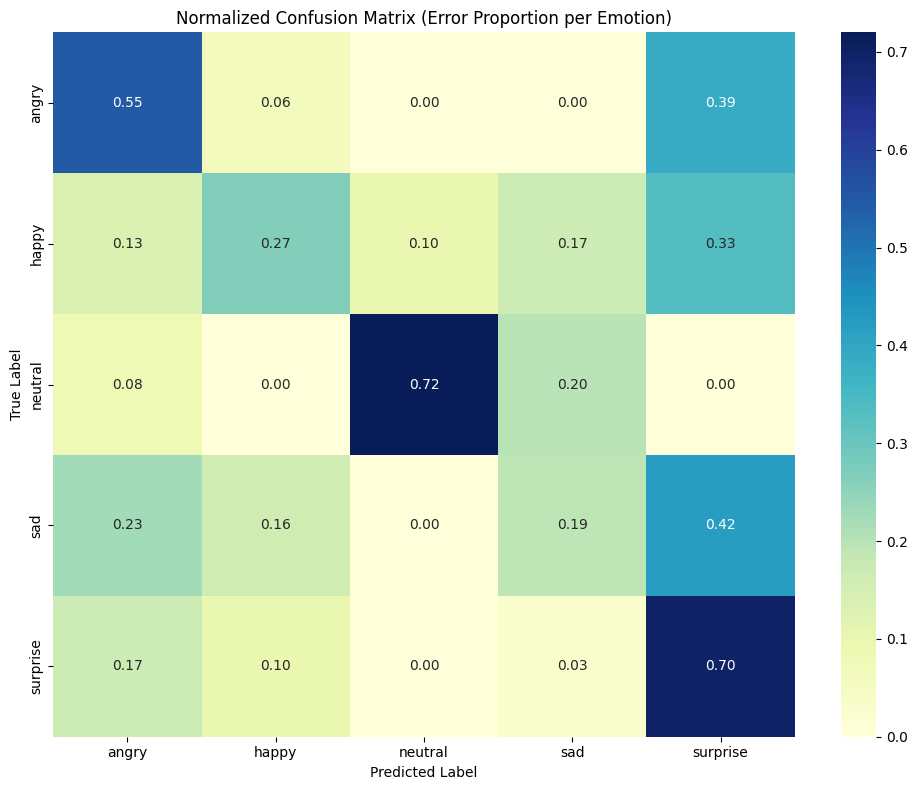

Model saved as 'bangla_ser_cnn_yamnet_model.h5'


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Import YAMNet model
import tensorflow_hub as hub
import tensorflow as tf

# Load YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function using YAMNet embeddings
def extract_features(file_path):
    # Load audio file
    wav_data, sr = librosa.load(file_path, sr=16000)  # YAMNet expects 16 kHz mono audio

    # Make sure audio is mono
    if len(wav_data.shape) > 1:
        wav_data = np.mean(wav_data, axis=1)

    # Ensure float32 data type for YAMNet
    wav_data = wav_data.astype(np.float32)

    # Get YAMNet embeddings
    scores, embeddings, log_mel_spectrogram = yamnet_model(wav_data)

    # Take the mean of embeddings across time segments to get a fixed-length feature vector
    mean_embedding = np.mean(embeddings.numpy(), axis=0)

    return mean_embedding

# Import YAMNet model
import tensorflow_hub as hub
import tensorflow as tf

# Load YAMNet model from TensorFlow Hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function using YAMNet embeddings
def extract_features(file_path):
    # Load audio file
    wav_data, sr = librosa.load(file_path, sr=16000)  # YAMNet expects 16 kHz mono audio

    # Make sure audio is mono
    if len(wav_data.shape) > 1:
        wav_data = np.mean(wav_data, axis=1)

    # Ensure float32 data type for YAMNet
    wav_data = wav_data.astype(np.float32)

    # Get YAMNet embeddings
    scores, embeddings, log_mel_spectrogram = yamnet_model(wav_data)

    # Take the mean of embeddings across time segments to get a fixed-length feature vector
    mean_embedding = np.mean(embeddings.numpy(), axis=0)

    return mean_embedding

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape for the model - no need for additional reshaping with YAMNet embeddings
# YAMNet embeddings are already flattened vectors
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized YAMNet Embeddings of Training Set')
plt.xlabel('Embedding Dimension')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape YAMNet embeddings for CNN processing
# Add an extra dimension for CNN channels
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Print reshaped dimensions
print("X_train reshaped shape for CNN:", X_train.shape)
print("X_val reshaped shape for CNN:", X_val.shape)
print("X_test reshaped shape for CNN:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Build combined CNN-YAMNet model
def build_cnn_yamnet_model(input_shape, num_classes):
    model = models.Sequential()

    # First Convolutional Layer processing YAMNet embeddings
    model.add(layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Second Convolutional Layer
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Additional Layer for more complex feature extraction
    model.add(layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling1D())  # Global pooling to handle variable length

    # Dense layers for classification
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model
input_shape = (X_train.shape[1], X_train.shape[2])  # (embedding_dim, channels)
num_classes = y_train.shape[1]
model = build_cnn_yamnet_model(input_shape, num_classes)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_cnn_yamnet_model.h5')
print("Model saved as 'bangla_ser_cnn_yamnet_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio using YAMNet
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for CNN-YAMNet model input
    features = features.reshape(1, -1, 1)  # Reshape for CNN (batch_size, features, channels)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

# Test prediction on a few samples with visualization
def visualize_predictions(num_samples=5):
    # Select random samples from test set
    sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)

    plt.figure(figsize=(15, num_samples*3))

    for i, idx in enumerate(sample_indices):
        sample_path = test_df['file_path'].iloc[idx]
        true_emotion = test_df['emotion'].iloc[idx]

        # Predict
        predicted_emotion, confidence, all_probs = predict_emotion(sample_path, model, scaler, label_encoder)

        # Plot audio waveform
        plt.subplot(num_samples, 2, 2*i+1)
        y, sr = librosa.load(sample_path, sr=None)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Sample {i+1}: True={true_emotion}, Pred={predicted_emotion} ({confidence:.2f})")

        # Plot prediction probabilities
        plt.subplot(num_samples, 2, 2*i+2)
        sns.barplot(x=label_encoder.classes_, y=all_probs)
        plt.title(f"Prediction Probabilities")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Uncomment to visualize predictions on test samples
# visualize_predictions(5)

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence, _ = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

### Bi-Lstm & CNN

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1024, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 512, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 256, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,877 (1.83 MB)

 Trainable params: 478,725 (1.83 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.4095 - loss: 1.2203 - val_accuracy: 0.4082 - val_loss: 1.3919 - learning_rate: 2.0000e-04
Epoch 35/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4664 - loss: 1.1863
Epoch 35: val_accuracy improved from 0.40816 to 0.41497, saving model to best_cnn_bilstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.4662 - loss: 1.1862 - val_accuracy: 0.4150 - val_loss: 1.3752 - learning_rate: 2.0000e-04
Epoch 36/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4664 - loss: 1.1684
Epoch 36: val_accuracy improved from 0.41497 to 0.42857, saving model to best_cnn_bilstm_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.4662 - loss: 1.1687 - val_accuracy: 0.4286 - val_loss: 1.4435 - learning_rate: 2.0000e-04
Epoch 37/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4262 - loss: 1.1707
Epoch 37: val_accuracy did not improve from 0.42857
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.4264 - loss: 1.1707 - val_accuracy: 0.4150 - val_loss: 1.4048 - learning_rate: 2.0000e-04
Epoch 38/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4530 - loss: 1.1465
Epoch 38: val_accuracy did not improve from 0.42857
37/37 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.4532 - loss: 1.1465 - val_accuracy: 0.4150 - val_loss: 1.3775 - learning_rate: 2.0000e-04
Epoch 39/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4384 - loss: 1.1469
Epoch 39: val_accuracy did not improve from 0.42857
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4386 - loss: 1.1470 - val_accuracy: 0.4082 - val_loss: 1.4799 - learning_rate: 2.0000e-04
Epoch 40/100
37/3


Epoch 45: ReduceLROnPlateau reducing learning rate to 1e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.5176 - loss: 1.0447 - val_accuracy: 0.4354 - val_loss: 1.4502 - learning_rate: 4.0000e-05
Epoch 46/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5359 - loss: 1.0336
Epoch 46: val_accuracy did not improve from 0.43537
37/37 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5355 - loss: 1.0338 - val_accuracy: 0.4286 - val_loss: 1.4520 - learning_rate: 1.0000e-05
Epoch 47/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5261 - loss: 1.0064
Epoch 47: val_accuracy did not improve from 0.43537
37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5262 - loss: 1.0069 - val_accuracy: 0.4218 - val_loss: 1.4486 - learning_rate: 1.0000e-05
Epoch 48/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5428 - loss: 1.0219
Epoch 48: val_accuracy did not improve from 0.43537
37/37 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5423 - loss: 1.0222 - val_accuracy: 0.4354 - 

37/37 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5051 - loss: 1.0327 - val_accuracy: 0.4422 - val_loss: 1.4598 - learning_rate: 1.0000e-05


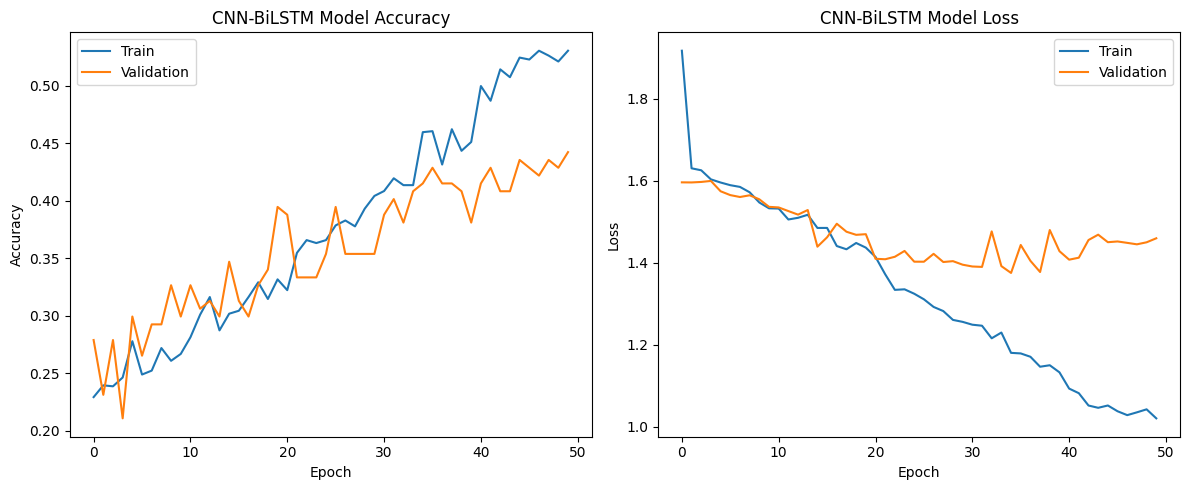

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 0.3681 - loss: 1.3549
Test Loss: 1.3924
Test Accuracy: 0.3673
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 560ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.36      0.39      0.38        31
       happy       0.26      0.20      0.23        30
     neutral       0.68      0.68      0.68        25
         sad       0.25      0.13      0.17        31
    surprise       0.30      0.50      0.38        30

    accuracy                           0.37       147
   macro avg       0.37      0.38      0.37       147
weighted avg       0.36      0.37      0.35       147



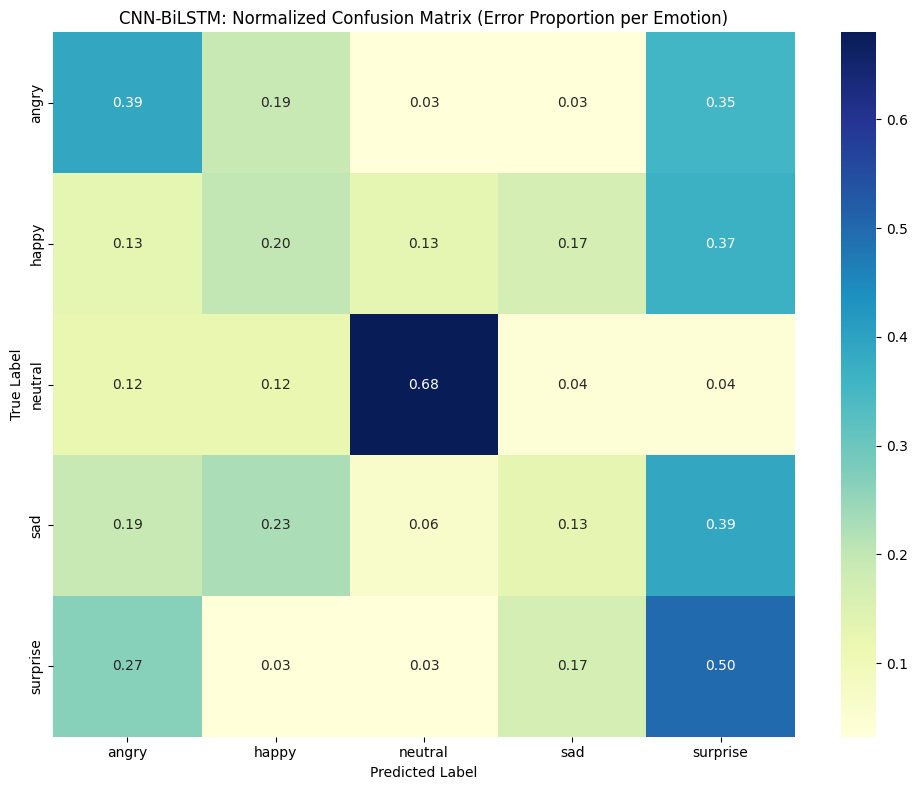

Model saved as 'bangla_ser_cnn_bilstm_model.h5'


In [ ]:
def build_cnn_bilstm_model(input_shape, num_classes):
    model = models.Sequential()

    # CNN Part - Extract local spectral features
    # First Convolutional Layer
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Second Convolutional Layer
    model.add(layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # BiLSTM Part - Capture temporal dependencies
    # First BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
    model.add(layers.BatchNormalization())

    # Second BiLSTM Layer
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
    model.add(layers.BatchNormalization())

    # Global Max Pooling - combine features across time steps
    model.add(layers.GlobalMaxPooling1D())

    # Dense layers for classification
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Create and compile the model
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]
model = build_cnn_bilstm_model(input_shape, num_classes)

# Compile with categorical crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_cnn_bilstm_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('CNN-BiLSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('CNN-BiLSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("CNN-BiLSTM: Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_cnn_bilstm_model.h5')
print("Model saved as 'bangla_ser_cnn_bilstm_model.h5'")

<ipython-input-8-a23de4065875>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


Train: 1173, Validation: 147, Test: 147


<ipython-input-8-a23de4065875>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
<ipython-input-8-a23de4065875>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


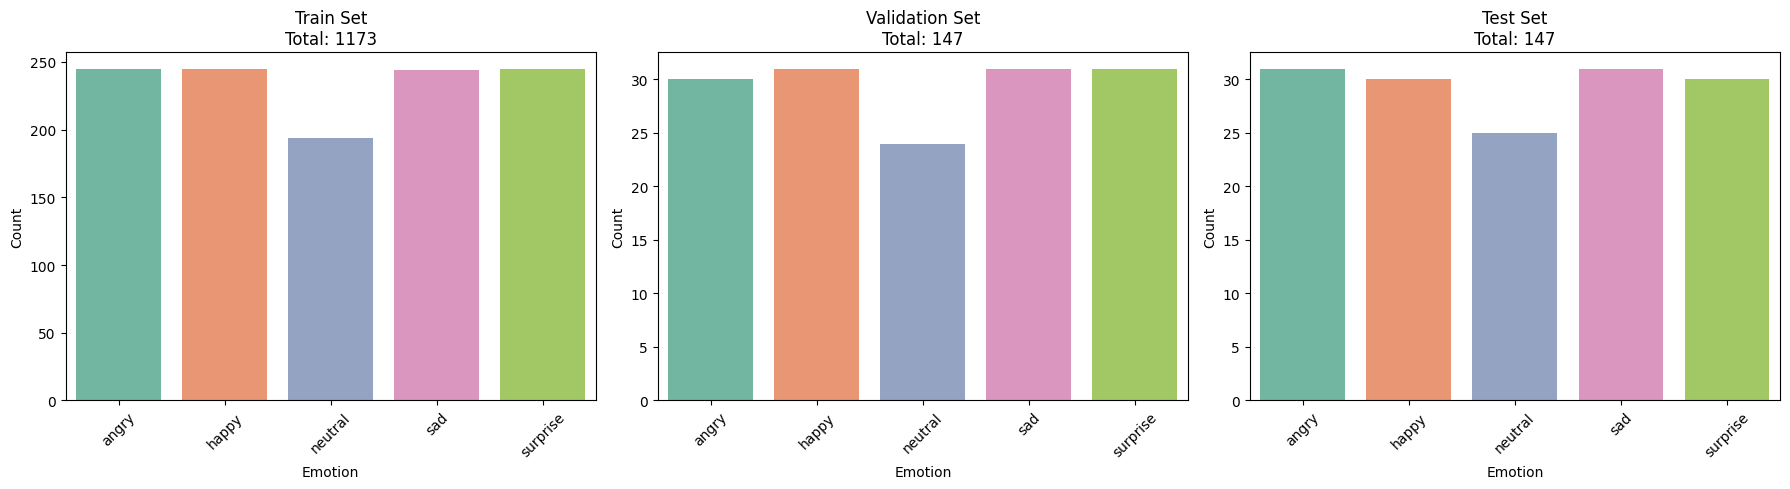

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


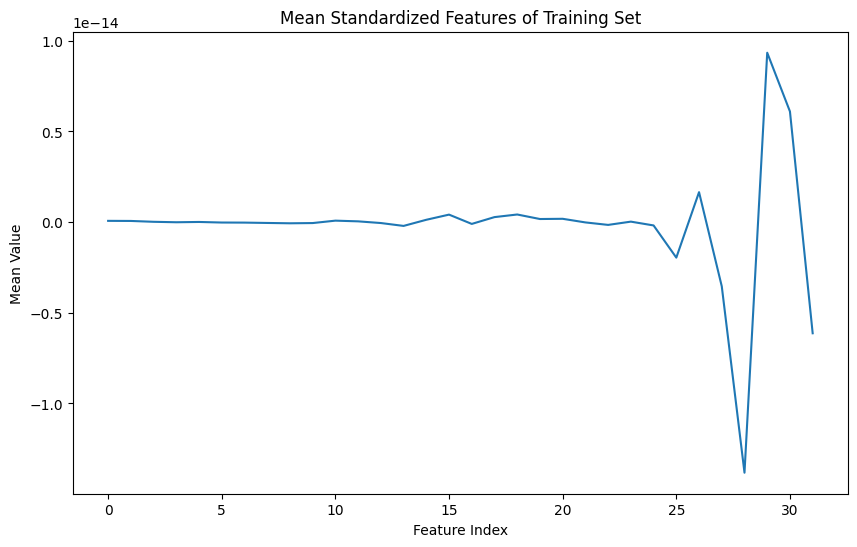

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 32, 1)
X_val reshaped shape: (147, 32, 1)
X_test reshaped shape: (147, 32, 1)
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 32, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 16, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,613 (1.48 MB)

...

37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.8539 - loss: 0.3812 - val_accuracy: 0.7415 - val_loss: 0.8915 - learning_rate: 0.0010
Epoch 14/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8900 - loss: 0.3088
Epoch 14: val_accuracy did not improve from 0.74150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.8901 - loss: 0.3084 - val_accuracy: 0.7075 - val_loss: 0.9489 - learning_rate: 0.0010
Epoch 15/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9093 - loss: 0.2581
Epoch 15: val_accuracy improved from 0.74150 to 0.74830, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.9090 - loss: 0.2588 - val_accuracy: 0.7483 - val_loss: 0.9670 - learning_rate: 0.0010
Epoch 16/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9092 - loss: 0.2317
Epoch 16: val_accuracy did not improve from 0.74830
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9090 - loss: 0.2323 - val_accuracy: 0.6939 - val_loss: 1.0883 - learning_rate: 0.0010
Epoch 17/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9127 - loss: 0.2091
Epoch 17: val_accuracy improved from 0.74830 to 0.76871, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9126 - loss: 0.2097 - val_accuracy: 0.7687 - val_loss: 0.9300 - learning_rate: 0.0010
Epoch 18/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9266 - loss: 0.1891
Epoch 18: val_accuracy did not improve from 0.76871

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9268 - loss: 0.1890 - val_accuracy: 0.7551 - val_loss: 1.0082 - learning_rate: 0.0010
Epoch 19/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9610 - loss: 0.1214
Epoch 19: val_accuracy improved from 0.76871 to 0.78912, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9612 - loss: 0.1212 - val_accuracy: 0.7891 - val_loss: 1.0189 - learning_rate: 2.0000e-04
Epoch 20/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9700 - loss: 0.0907
Epoch 20: val_accuracy improved from 0.78912 to 0.79592, saving model to best_model.h5


37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9701 - loss: 0.0906 - val_accuracy: 0.7959 - val_loss: 1.0409 - learning_rate: 2.0000e-04
Epoch 21/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9847 - loss: 0.0690
Epoch 21: val_accuracy did not improve from 0.79592
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9848 - loss: 0.0690 - val_accuracy: 0.7755 - val_loss: 1.0783 - learning_rate: 2.0000e-04
Epoch 22/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9708 - loss: 0.0873
Epoch 22: val_accuracy did not improve from 0.79592
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9710 - loss: 0.0870 - val_accuracy: 0.7755 - val_loss: 1.0754 - learning_rate: 2.0000e-04
Epoch 23/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9905 - loss: 0.0589
Epoch 23: val_accuracy did not improve from 0.79592

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.9904 - loss: 0

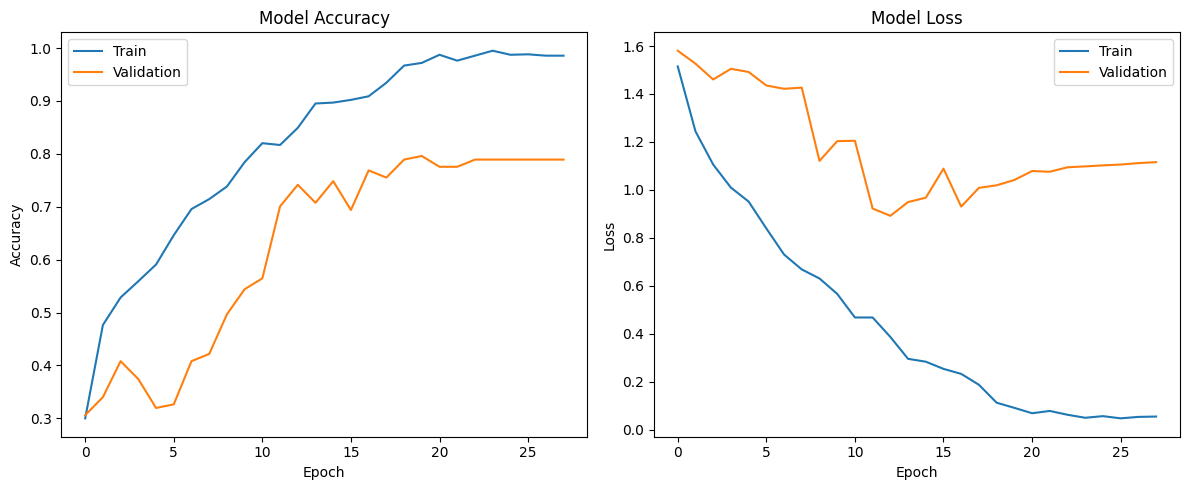

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6707 - loss: 0.8251
Test Loss: 0.7969
Test Accuracy: 0.6735
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.80      0.65      0.71        31
       happy       0.46      0.53      0.49        30
     neutral       0.95      0.76      0.84        25
         sad       0.77      0.77      0.77        31
    surprise       0.56      0.67      0.61        30

    accuracy                           0.67       147
   macro avg       0.71      0.68      0.69       147
weighted avg       0.70      0.67      0.68       147



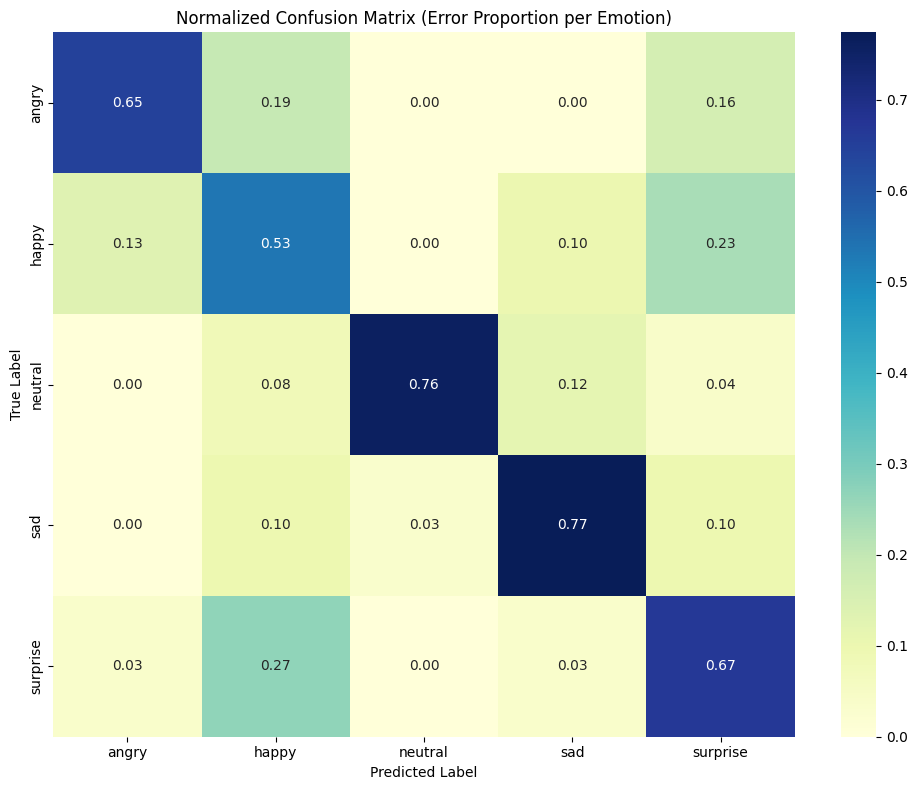

Model saved as 'bangla_ser_cnn_model.h5'


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for CNN model input (adding channel dimension)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Handle class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights based on training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary for use in model.fit
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# Import required libraries
from tensorflow.keras import layers, models
import numpy as np

# Ensure features are not averaged (retain time dimension)
# Example: MFCCs with shape (n_samples, n_time_steps, n_coefficients)
# If using current code, reshape to (samples, features, 1)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build CNN-Bi-LSTM model
def build_cnn_bilstm_model(input_shape, num_classes):
    model = models.Sequential()

    # 1D CNN Layer
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Bi-LSTM Layers
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
    model.add(layers.BatchNormalization())
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False)))  # Return sequences=False for final Bi-LSTM

    # Dense Layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define input shape and number of classes
input_shape = (X_train.shape[1], X_train.shape[2])  # (features, 1)
num_classes = y_train.shape[1]

# Build and compile the model
model = build_cnn_bilstm_model(input_shape, num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Define callbacks for early stopping and model checkpointing
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the trained model
model.save('bangla_ser_cnn_model.h5')
print("Model saved as 'bangla_ser_cnn_model.h5'")

# Example function for predicting emotion on new audio
def predict_emotion(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for model input
    features = features.reshape(1, -1, 1)  # Reshape for CNN (batch_size, feature_length, channels)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index and probability
    predicted_index = np.argmax(prediction)
    probability = prediction[predicted_index]

    # Convert index to emotion label
    emotion = label_encoder.classes_[predicted_index]

    return emotion, probability, prediction

# Test prediction on a few samples with visualization
def visualize_predictions(num_samples=5):
    # Select random samples from test set
    sample_indices = np.random.choice(len(test_df), min(num_samples, len(test_df)), replace=False)

    plt.figure(figsize=(15, num_samples*3))

    for i, idx in enumerate(sample_indices):
        sample_path = test_df['file_path'].iloc[idx]
        true_emotion = test_df['emotion'].iloc[idx]

        # Predict
        predicted_emotion, confidence, all_probs = predict_emotion(sample_path, model, scaler, label_encoder)

        # Plot audio waveform
        plt.subplot(num_samples, 2, 2*i+1)
        y, sr = librosa.load(sample_path, sr=None)
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Sample {i+1}: True={true_emotion}, Pred={predicted_emotion} ({confidence:.2f})")

        # Plot prediction probabilities
        plt.subplot(num_samples, 2, 2*i+2)
        sns.barplot(x=label_encoder.classes_, y=all_probs)
        plt.title(f"Prediction Probabilities")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Uncomment to visualize predictions on test samples
# visualize_predictions(5)

# Example usage (comment out if not needed)
# sample_path = test_df['file_path'].iloc[0]  # First test sample
# predicted_emotion, confidence, _ = predict_emotion(sample_path, model, scaler, label_encoder)
# print(f"Predicted emotion: {predicted_emotion} (Confidence: {confidence:.2f})")

In [ ]:
#might get errors
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from tqdm import tqdm

def extract_features(file_path, augment=False):
    y, sr = librosa.load(file_path, sr=None)
    if augment:
        # Apply time-stretching and pitch shifting
        y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.9, 1.1))
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-2, 2))
        # Add Gaussian noise
        noise = np.random.randn(len(y)) * np.random.uniform(0, 0.005)
        y += noise
    # Extract MFCCs (keep time dimension)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return mfcc.T  # Shape: (time_steps, n_mfcc)

# Load dataset (replace with your actual file paths)
def load_data(data_dir):
    features = []
    labels = []
    for emotion_dir in os.listdir(data_dir):
        emotion_path = os.path.join(data_dir, emotion_dir)
        if not os.path.isdir(emotion_path):
            continue
        for file in os.listdir(emotion_path):
            file_path = os.path.join(emotion_path, file)
            if file.endswith(".wav"):
                # Extract features without averaging
                mfcc = extract_features(file_path, augment=True)
                features.append(mfcc)
                labels.append(emotion_dir)
    return np.array(features), np.array(labels)

# Example: Replace 'data_dir' with your dataset path
data_dir = "path/to/BanglaSER"
X, y = load_data(data_dir)


# Pad sequences to equal length
max_len = max(len(seq) for seq in X)
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=max_len, padding='post', dtype='float32')

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y_categorical, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Feature standardization
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)


def build_cnn_bilstm_model(input_shape, num_classes):
    model = models.Sequential()

    # CNN Layers
    model.add(layers.Input(shape=input_shape))  # (time_steps, n_mfcc)
    model.add(layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # Bi-LSTM Layers
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
    model.add(layers.BatchNormalization())
    model.add(layers.Bidirectional(layers.LSTM(64)))

    # Dense Layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

input_shape = X_train_scaled.shape[1:]  # (time_steps, n_mfcc)
num_classes = y_categorical.shape[1]
model = build_cnn_bilstm_model(input_shape, num_classes)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, min_lr=1e-6)
]

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(np.argmax(y_train, axis=1)), y=np.argmax(y_train, axis=1))
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix and classification report
y_pred = model.predict(X_test_scaled)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/BanglaSER'